In [1]:
import sys
from pathlib import Path

# add the directory that contains `package/`
sys.path.insert(0, str(Path("..").resolve()))
sys.path

['/home/adrian/Projects/InsDelGLM',
 '/home/adrian/miniforge3/envs/insdel_glm/lib/python311.zip',
 '/home/adrian/miniforge3/envs/insdel_glm/lib/python3.11',
 '/home/adrian/miniforge3/envs/insdel_glm/lib/python3.11/lib-dynload',
 '',
 '/home/adrian/miniforge3/envs/insdel_glm/lib/python3.11/site-packages']

In [2]:
import torch
import pandas as pd
import numpy as np
import logomaker
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from collections import Counter
from helpers.seq_logo import DNALandscape
from helpers.conf_matrix import plot_evaluation_results

from modules.dna_tokenizer import DNATokenizer
from modules.custom_bert import DNABertForMaskedLM

/home/adrian/miniforge3/envs/insdel_glm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- SETUP ---
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

# Load Tokenizer & Model

baseline_model_path = "../model/Panther_baseline_100k_1e-5"
baseline_tokenizer = DNATokenizer(deletion_token=False)
baseline_model = DNABertForMaskedLM.from_pretrained(baseline_model_path)
baseline_model.to(device)
baseline_model.eval()

model_path = "../model/Panther_deletion_100k_1e-5"
tokenizer = DNATokenizer(deletion_token=True)
model = DNABertForMaskedLM.from_pretrained(model_path)
model.to(device)
model.eval()


# Load Data
test_df = pd.read_parquet("../data/simulated/baseline_test.parquet")
print(f"Loaded {len(test_df)} test sequences.")

# Load Motifs
with open("../data/simulated/motifs.txt", "r") as f:
    motifs = [line.strip() for line in f.readlines()]
MOTIF_A = motifs[0]
MOTIF_B = motifs[1]
print(f"Ground Truth Motifs:\nMotif A: {MOTIF_A}\nMotif B: {MOTIF_B}")

Using device:  cuda
Loaded 20000 test sequences.
Ground Truth Motifs:
Motif A: CGTAGGTC
Motif B: GTAACGCTCC


In [4]:
def precompute_motif_metadata(df, motif_map):
    """
    Scans the dataset ONCE and saves start/end indices for all motifs.
    """
    df_meta = df.copy()

    print("Pre-computing motif positions...")
    for name, seq in motif_map.items():
        # Find start index (-1 if not found)
        df_meta[f'{name}_start'] = df_meta['sequences'].str.find(seq)

        # Calculate end index
        df_meta[f'{name}_end'] = df_meta.apply(
            lambda x: x[f'{name}_start'] + len(seq) if x[f'{name}_start'] != -1 else -1,
            axis=1
        )

    return df_meta


# --- EXECUTE ---
motif_map = {
    "Motif_A": MOTIF_A,
    "Motif_B": MOTIF_B
}

test_df_enriched = precompute_motif_metadata(test_df, motif_map)
print("Metadata computed. Sample:")
test_df_enriched[[col for col in test_df_enriched.columns if 'start' in col]].head()

Pre-computing motif positions...
Metadata computed. Sample:


,Motif_A_start,Motif_B_start
0,-1,5
1,7,-1
2,-1,14
3,20,-1
4,-1,18


In [5]:
test_df_enriched

,sequences,labels,id,Motif_A_start,Motif_A_end,Motif_B_start,Motif_B_end
0,CAGTTGTAACGCTCCCGCATACGAACTAGT,B,91157,-1,-1,5,15
1,TCTCTGCCGTAGGTCCCACAACGGCTCTGG,A,51550,7,15,-1,-1
2,GTGTCCGGAATAATGTAACGCTCCCCATTG,B,46267,-1,-1,14,24
3,AAATTGATCTAAGGGCCCTGCGTAGGTCGC,A,8346,20,28,-1,-1
4,GCCCACACCGGGCTATACGTAACGCTCCGT,B,32914,-1,-1,18,28
...,...,...,...,...,...,...,...
19995,CAGCGTAGGTCTCTTGTTTCATTGTGGCTT,A,81093,3,11,-1,-1
19996,TGACTCAGCCTTTAGTAACGCTCCGCCACG,B,82079,-1,-1,14,24
19997,GTAACGCTCCCGTAGGCCTAAGCTGTATCT,B,57460,-1,-1,0,10
19998,CGCTCAGGTAACGCTCCCTACCAATGTGTG,B,152,-1,-1,7,17


In [6]:
print("baseline_mask_token_id:", baseline_tokenizer.mask_token_id)
print("baseline_vocab_size:", baseline_model.config.vocab_size)
print("mask_token_id:", tokenizer.mask_token_id)
print("vocab_size:", model.config.vocab_size)

baseline_mask_token_id: 5
baseline_vocab_size: 8
mask_token_id: 6
vocab_size: 9


In [7]:
def plot_iterative_masking_logo(model, tokenizer, sequences, motif_seq):
    model.eval()
    motif_len = len(motif_seq)

    # FIX: Add '-' to the vocab order so we can see gap predictions
    self.vocab_order = ["A", "C", "G", "T"]
    if "-" in self.tokenizer.get_vocab():
        self.vocab_order.append("-")

    # Increase shape to 5 for the new token
    position_accumulators = np.zeros((motif_len, len(vocab_order)))
    position_counts = np.zeros(motif_len)

    # Get IDs for A, C, G, T, -
    dna_ids = [tokenizer.tokens_to_ids[n] for n in vocab_order]

    print(f"Running Iterative Masking for {motif_seq}...")

    # Limit to 500 for speed
    count_processed = 0

    for seq in tqdm(sequences):
        start_idx = seq.find(motif_seq)
        if start_idx == -1: continue

        encoded = tokenizer(seq, return_tensors="pt")
        input_ids_original = encoded["input_ids"].to(device)
        attention_mask = encoded["attention_mask"].to(device)

        abs_start = start_idx + 1  # +1 for CLS
        if abs_start + motif_len > input_ids_original.shape[1]: continue

        for i in range(motif_len):
            target_pos = abs_start + i
            input_ids_masked = input_ids_original.clone()
            input_ids_masked[0, target_pos] = tokenizer.mask_token_id

            with torch.no_grad():
                outputs = model(input_ids=input_ids_masked, attention_mask=attention_mask, return_dict=True)
                probs = F.softmax(outputs.logits[0, target_pos], dim=-1)

            # Extract probs for A, C, G, T, AND -
            position_accumulators[i] += probs[dna_ids].cpu().numpy()
            position_counts[i] += 1

        count_processed += 1
        if count_processed >= 500: break

    if np.sum(position_counts) == 0: return

    # Plot
    mean_probs = position_accumulators / position_counts[:, None]
    df_logo = pd.DataFrame(mean_probs, columns=vocab_order)

    # Ground Truth Matrix
    ground_truth_matrix = np.zeros((motif_len, 5)) # Shape 5
    for i, char in enumerate(motif_seq):
        if char in vocab_order:
            ground_truth_matrix[i, vocab_order.index(char)] = 1.0

    df_truth = pd.DataFrame(ground_truth_matrix, columns=vocab_order)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

    # Logomaker automatically handles the 5th column
    logomaker.Logo(df_logo, ax=ax1, shade_below=.5, fade_below=.5, font_name='Arial Rounded MT Bold')
    ax1.set_title(f"Model Prediction (Iterative Masking)")
    ax1.set_ylabel("Probability")

    logomaker.Logo(df_truth, ax=ax2, shade_below=.5, fade_below=.5, font_name='Arial Rounded MT Bold')
    ax2.set_title(f"Ground Truth ({motif_seq})")
    ax2.set_ylabel("Truth")
    plt.xticks(range(motif_len), list(motif_seq))
    plt.tight_layout()
    plt.show()

In [8]:
# Initialize (Pass model once). For font, you can just use the default in the helper.
baseline_viz = DNALandscape(baseline_model, baseline_tokenizer, seq_len = 30, font="Source Code Pro", use_ic=True)
viz = DNALandscape(model, tokenizer, seq_len = 30, font="Source Code Pro", use_ic=True)

--- Scanning: Single Seq | Label: GTAACGCTCC ---


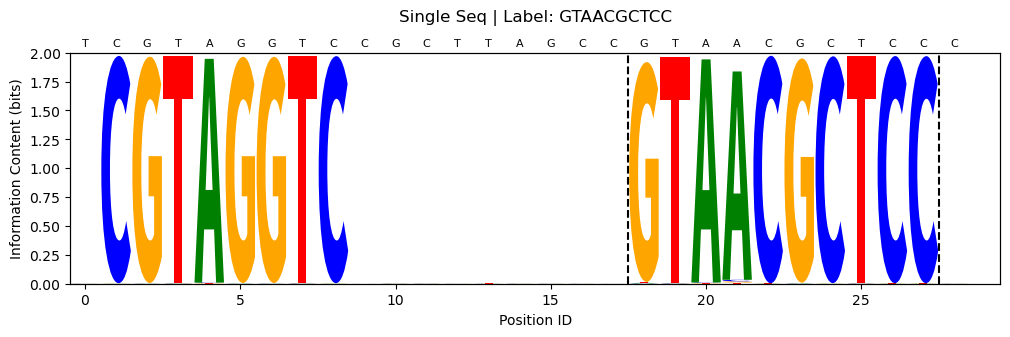

--- Scanning: Single Seq | Label: GTAACGCTCC ---


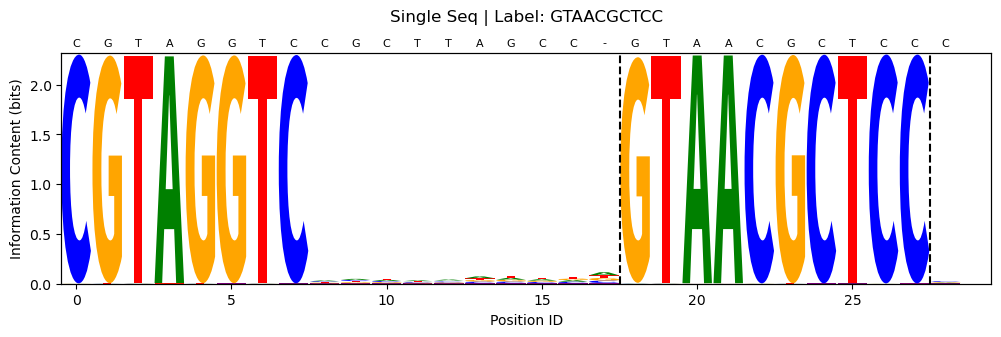

In [22]:
baseline_viz.plot_string(f"T{MOTIF_A}CGCTTAGCC{MOTIF_B}C", motif_seq=MOTIF_B)
viz.plot_string(f"{MOTIF_A}CGCTTAGCC-{MOTIF_B}C", motif_seq=MOTIF_B)

--- Scanning: Single Seq | ID: 152 | Label: B ---


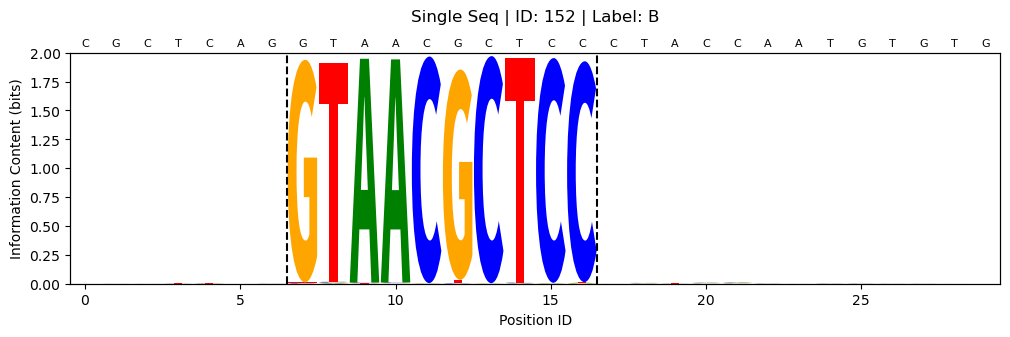

--- Scanning: Single Seq | ID: 152 | Label: B ---


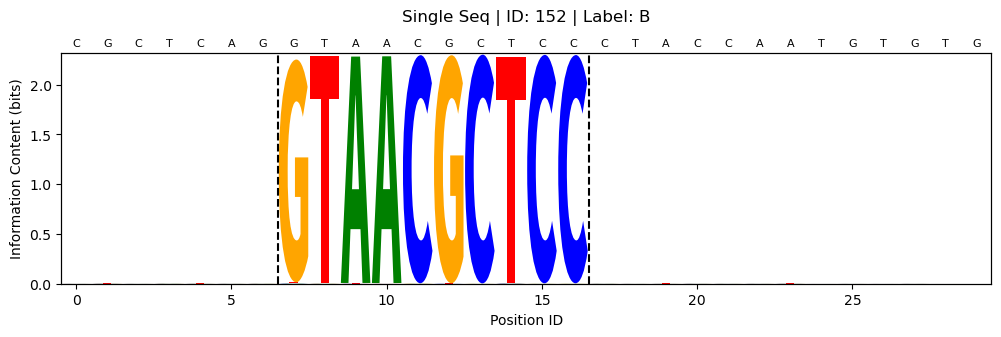

In [10]:
baseline_viz.plot_single(test_df_enriched, 152, motif_seq=MOTIF_B)
viz.plot_single(test_df_enriched, 152, motif_seq=MOTIF_B)

In [11]:
# aggregated per position
#viz.plot_aggregated(test_df_enriched, "Motif_A", MOTIF_A)
viz.generate_aggregated_gif(test_df_enriched, "Motif_A", MOTIF_A, filename="example_explanations/Motif_A_aggregated.gif", fps=2)
#viz.plot_aggregated(test_df_enriched, "Motif_B", MOTIF_B)
viz.generate_aggregated_gif(test_df_enriched, "Motif_B", MOTIF_B, filename="example_explanations/Motif_B_aggregated.gif", fps=2)

baseline_viz.generate_aggregated_gif(test_df_enriched, "Motif_A", MOTIF_A, filename="example_explanations/baseline_Motif_A_aggregated.gif", fps=2)
#viz.plot_aggregated(test_df_enriched, "Motif_B", MOTIF_B)
baseline_viz.generate_aggregated_gif(test_df_enriched, "Motif_B", MOTIF_B, filename="example_explanations/baseline_Motif_B_aggregated.gif", fps=2)


--- Generating GIF for Motif_A (23 frames) ---
Rendering Frame: Start Index 0 (N=1942)...
Rendering Frame: Start Index 1 (N=1387)...
Rendering Frame: Start Index 2 (N=711)...
Rendering Frame: Start Index 3 (N=363)...
Rendering Frame: Start Index 4 (N=337)...
Rendering Frame: Start Index 5 (N=312)...
Rendering Frame: Start Index 6 (N=349)...
Rendering Frame: Start Index 7 (N=383)...
Rendering Frame: Start Index 8 (N=401)...
Rendering Frame: Start Index 9 (N=378)...
Rendering Frame: Start Index 10 (N=398)...
Rendering Frame: Start Index 11 (N=368)...
Rendering Frame: Start Index 12 (N=389)...
Rendering Frame: Start Index 13 (N=350)...
Rendering Frame: Start Index 14 (N=361)...
Rendering Frame: Start Index 15 (N=350)...
Rendering Frame: Start Index 16 (N=399)...
Rendering Frame: Start Index 17 (N=402)...
Rendering Frame: Start Index 18 (N=354)...
Rendering Frame: Start Index 19 (N=392)...
Rendering Frame: Start Index 20 (N=344)...
Rendering Frame: Start Index 21 (N=387)...
Rendering Frame

KeyboardInterrupt: 

In [ ]:
test_df_enriched